# 🚗 Car Position and Velocity Estimation using Data Assimilation

In this problem, we simulate the motion of a car in one dimension. The state of the system consists of two variables:

- **Position** \([m]\)
- **Velocity** \([m/s]\)

The system evolves in time according to a simple kinematic model, assuming constant velocity. However, only **noisy position observations** are available at discrete time steps.

The goal is to use different data assimilation methods (e.g., Nudging, Kalman Filter, Ensemble Kalman Filter) to estimate the true position and velocity of the car more accurately by combining:

- A **model prediction** of the system's behavior, and  
- **Partial and noisy observations** (only the position)

This setup allows us to compare the effectiveness of various assimilation methods in filtering out noise and reconstructing unobserved state variables (like velocity) from incomplete data.


## Car Position Estimation with Nudging

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import mean_squared_error
np.random.seed(42)

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'legend.fontsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20
})


In [4]:
# Parameters
dt = 0.1
T = 10
steps = int(T / dt)
time = np.linspace(0, T, steps)

# True state [position, velocity]
v_true = 1.5
x_true = np.zeros((steps, 2))
x_true[0] = [0, v_true]

for k in range(1, steps):
    x_true[k, 0] = x_true[k-1, 0] + dt * x_true[k-1, 1]
    x_true[k, 1] = x_true[k-1, 1]

print(steps)

100


In [5]:
# Noisy position observations
pos_noise_std = 1.0
y_obs = x_true[:, 0] + np.random.normal(0, pos_noise_std, size=steps)

In [6]:
# Initial guess with wrong initial condition
x_model = np.zeros((steps, 2))
x_model[0] = [2.0, 1.0]

for k in range(1, steps):
    x_model[k, 0] = x_model[k-1, 0] + dt * x_model[k-1, 1]
    x_model[k, 1] = x_model[k-1, 1]

In [7]:
# Apply simple nudging
alpha = 0.2
x_adjusted = np.zeros_like(x_model)
x_adjusted[0] = x_model[0]

for k in range(1, steps):
    dx = x_adjusted[k-1, 1] + alpha * (y_obs[k-1] - x_adjusted[k-1, 0])
    x_adjusted[k, 0] = x_adjusted[k-1, 0] + dt * dx
    x_adjusted[k, 1] = x_adjusted[k-1, 1]

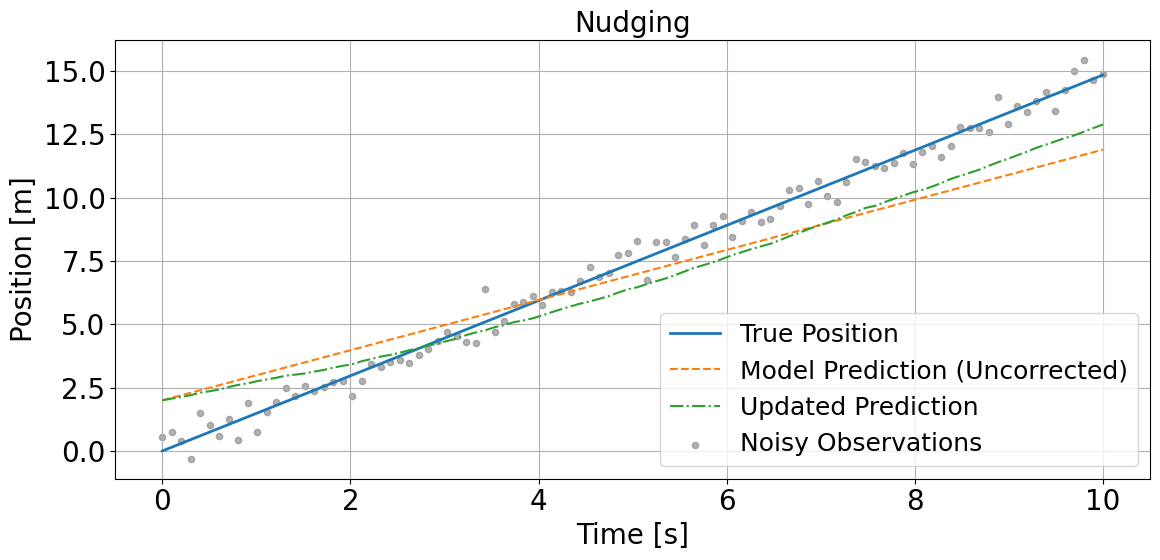

In [26]:

plt.rcParams.update({
    'font.size': 20,              # Tamaño base del texto
    'axes.titlesize': 20,         # Título del gráfico
    'axes.labelsize': 20,         # Ejes X e Y
    'legend.fontsize': 20,        # Leyenda
    'xtick.labelsize': 20,        # Ticks en eje X
    'ytick.labelsize': 20         # Ticks en eje Y
})

# Plot with all components (Nudging)
plt.figure(figsize=(12, 6))
plt.plot(time, x_true[:, 0], label='True Position', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--')
plt.plot(time, x_adjusted[:, 0], label='Updated Prediction', linestyle='-.')
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.6)

plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.title('Nudging')
plt.legend(loc='lower right', fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.show()

# Alpha analysis

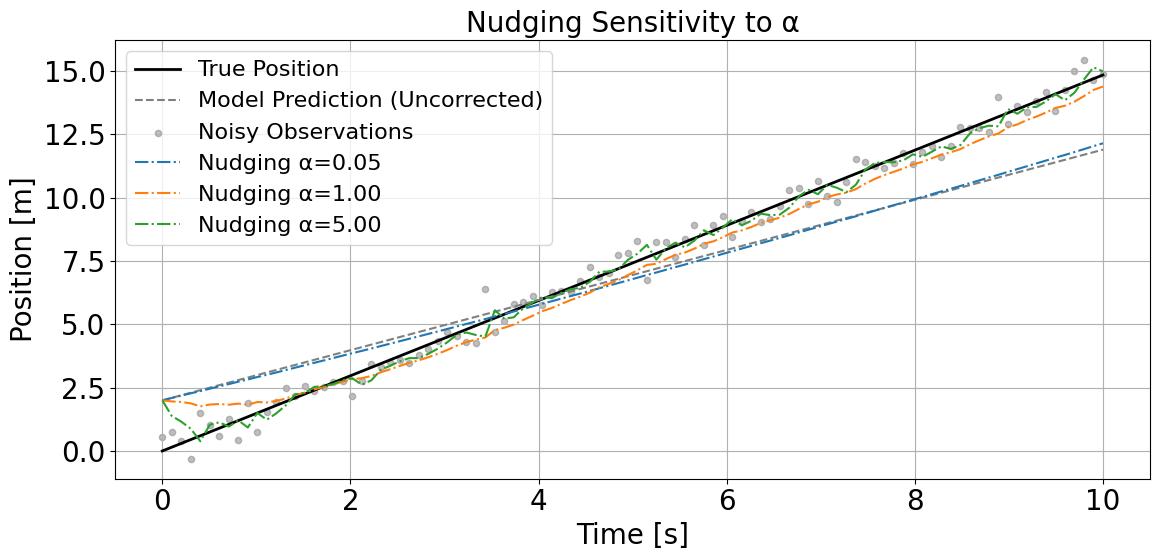

In [29]:
alphas = [0.05, 1.0, 5.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(alphas)))

plt.figure(figsize=(12, 6))
plt.plot(time, x_true[:, 0], label='True Position', color='black', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--', color='gray')
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.5)

for alpha, color in zip(alphas, colors):
    x_adj = np.zeros_like(x_model)
    x_adj[0] = x_model[0]
    for k in range(1, steps):
        dx = x_adj[k-1, 1] + alpha * (y_obs[k-1] - x_adj[k-1, 0])
        x_adj[k, 0] = x_adj[k-1, 0] + dt * dx
        x_adj[k, 1] = x_adj[k-1, 1]
    plt.plot(time, x_adj[:, 0], label=f'Nudging α={alpha:.2f}', linestyle='-.')

plt.xlabel('Time [s]', fontsize=20)
plt.ylabel('Position [m]', fontsize=20)
plt.title('Nudging Sensitivity to α', fontsize=20)
plt.legend(loc='upper left', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


## Car Position Estimation with Kalman Filter

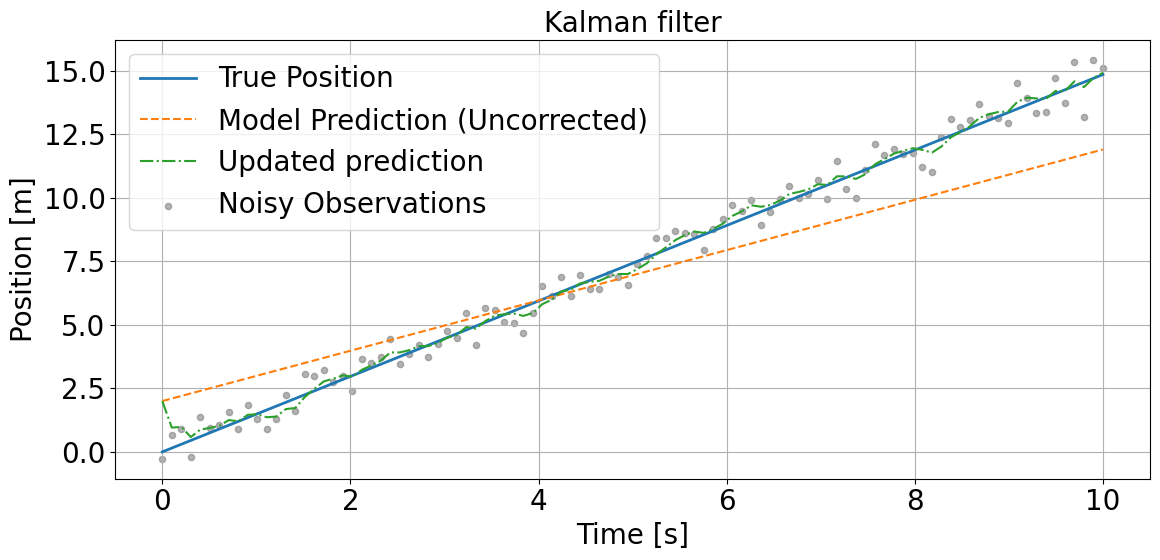

In [ ]:
# Kalman Filter parameters
F = np.array([[1, dt], [0, 1]])
H = np.array([[1, 0]])
Q = np.array([[0.01, 0], [0, 0.01]])  # model noise
R = np.array([[pos_noise_std**2]])   # observation noise
I = np.eye(2)

# Initial estimates

x_kf = np.zeros((steps, 2))
x_kf[0] = [2.0, 1.0]
P = np.eye(2)

for k in range(1, steps):
    # Predict
    x_pred = F @ x_kf[k-1]
    P_pred = F @ P @ F.T + Q

    # Update
    y = y_obs[k] - H @ x_pred
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    x_kf[k] = x_pred + K @ y
    P = (I - K @ H) @ P_pred

# Plot with all components
plt.figure(figsize=(12, 6))
plt.plot(time, x_true[:, 0], label='True Position', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--')
plt.plot(time, x_kf[:, 0], label='Updated prediction', linestyle='-.')
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.6)
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.title('Kalman filter')
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()

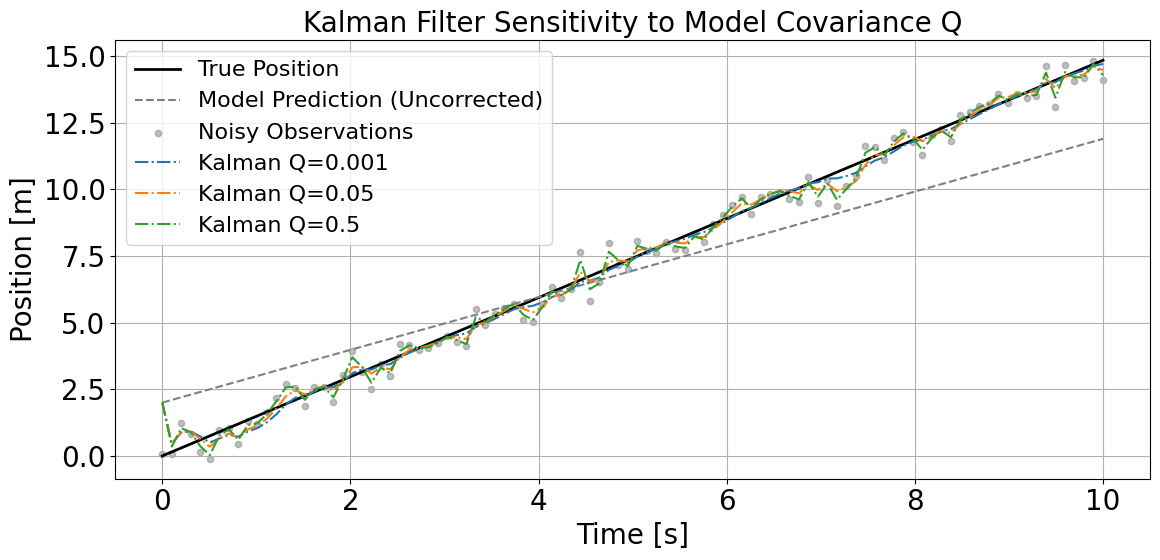

In [37]:
# Parámetros base
dt = 0.1
T = 10
steps = int(T / dt)
time = np.linspace(0, T, steps)
v_true = 1.5
pos_noise_std = 0.5

# Estado verdadero
x_true = np.zeros((steps, 2))
x_true[0] = [0, v_true]
for k in range(1, steps):
    x_true[k, 0] = x_true[k-1, 0] + dt * x_true[k-1, 1]
    x_true[k, 1] = x_true[k-1, 1]

# Observaciones
y_obs = x_true[:, 0] + np.random.normal(0, pos_noise_std, steps)

# Modelo base (sin corrección)
x_model = np.zeros((steps, 2))
x_model[0] = [2.0, 1.0]
for k in range(1, steps):
    x_model[k, 0] = x_model[k-1, 0] + dt * x_model[k-1, 1]
    x_model[k, 1] = x_model[k-1, 1]

# Valores de Q a comparar
Q_values = [0.001, 0.05, 0.5]
colors = ['tab:green', 'tab:orange', 'tab:blue']

plt.figure(figsize=(12, 6))
plt.plot(time, x_true[:, 0], label='True Position', color='black', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--', color='gray')
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.5)

for Q_val, color in zip(Q_values, colors):
    F = np.array([[1, dt], [0, 1]])
    H = np.array([[1, 0]])
    Q = np.array([[Q_val, 0], [0, Q_val]])
    R = np.array([[pos_noise_std**2]])
    I = np.eye(2)

    x_kf = np.zeros((steps, 2))
    x_kf[0] = [2.0, 1.0]
    P = np.eye(2)

    for k in range(1, steps):
        x_pred = F @ x_kf[k-1]
        P_pred = F @ P @ F.T + Q
        y = y_obs[k] - H @ x_pred
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)
        x_kf[k] = x_pred + K @ y
        P = (I - K @ H) @ P_pred

    plt.plot(time, x_kf[:, 0], label=f'Kalman Q={Q_val}', linestyle='-.')

plt.xlabel('Time [s]', fontsize=20)
plt.ylabel('Position [m]', fontsize=20)
plt.title('Kalman Filter Sensitivity to Model Covariance Q', fontsize=20)
plt.legend(fontsize=16, loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


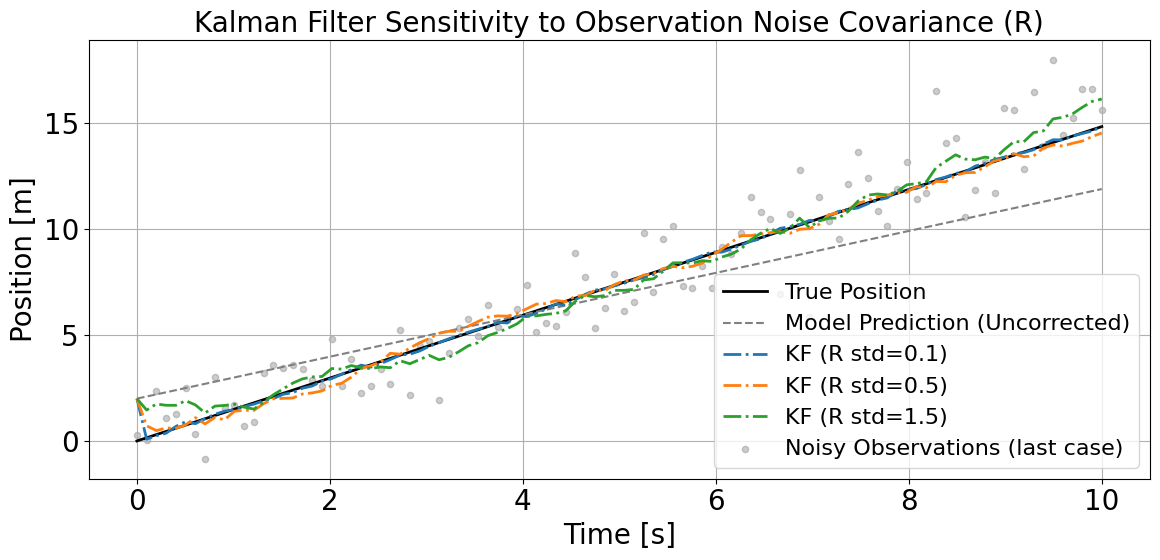

In [38]:
# Parámetros base
dt = 0.1
T = 10
steps = int(T / dt)
time = np.linspace(0, T, steps)
v_true = 1.5

# Estado verdadero
x_true = np.zeros((steps, 2))
x_true[0] = [0, v_true]
for k in range(1, steps):
    x_true[k, 0] = x_true[k-1, 0] + dt * x_true[k-1, 1]
    x_true[k, 1] = x_true[k-1, 1]

# Modelo inicial (sin corrección)
x_model = np.zeros((steps, 2))
x_model[0] = [2.0, 1.0]
for k in range(1, steps):
    x_model[k, 0] = x_model[k-1, 0] + dt * x_model[k-1, 1]
    x_model[k, 1] = x_model[k-1, 1]

# Diferentes niveles de ruido en la observación (R)
obs_std_values = [0.1, 0.5, 1.5]  # desviación estándar
colors = ['tab:blue', 'tab:orange', 'tab:green']

plt.figure(figsize=(12, 6))
plt.plot(time, x_true[:, 0], label='True Position', color='black', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--', color='gray')

for std, color in zip(obs_std_values, colors):
    y_obs = x_true[:, 0] + np.random.normal(0, std, steps)  # Observaciones con ese ruido

    # Filtro de Kalman
    F = np.array([[1, dt], [0, 1]])
    H = np.array([[1, 0]])
    Q = np.array([[0.01, 0], [0, 0.01]])  # Fijo para comparar
    R = np.array([[std**2]])
    I = np.eye(2)

    x_kf = np.zeros((steps, 2))
    x_kf[0] = [2.0, 1.0]
    P = np.eye(2)

    for k in range(1, steps):
        x_pred = F @ x_kf[k-1]
        P_pred = F @ P @ F.T + Q
        y = y_obs[k] - H @ x_pred
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)
        x_kf[k] = x_pred + K @ y
        P = (I - K @ H) @ P_pred

    plt.plot(time, x_kf[:, 0], linestyle='-.', linewidth=2, label=f'KF (R std={std})', color=color)

# Añadir observaciones de uno de los casos
plt.scatter(time, y_obs, label='Noisy Observations (last case)', color='gray', s=20, alpha=0.4)

# Personalización del gráfico
plt.xlabel('Time [s]', fontsize=20)
plt.ylabel('Position [m]', fontsize=20)
plt.title('Kalman Filter Sensitivity to Observation Noise Covariance (R)', fontsize=20)
plt.legend(fontsize=16, loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


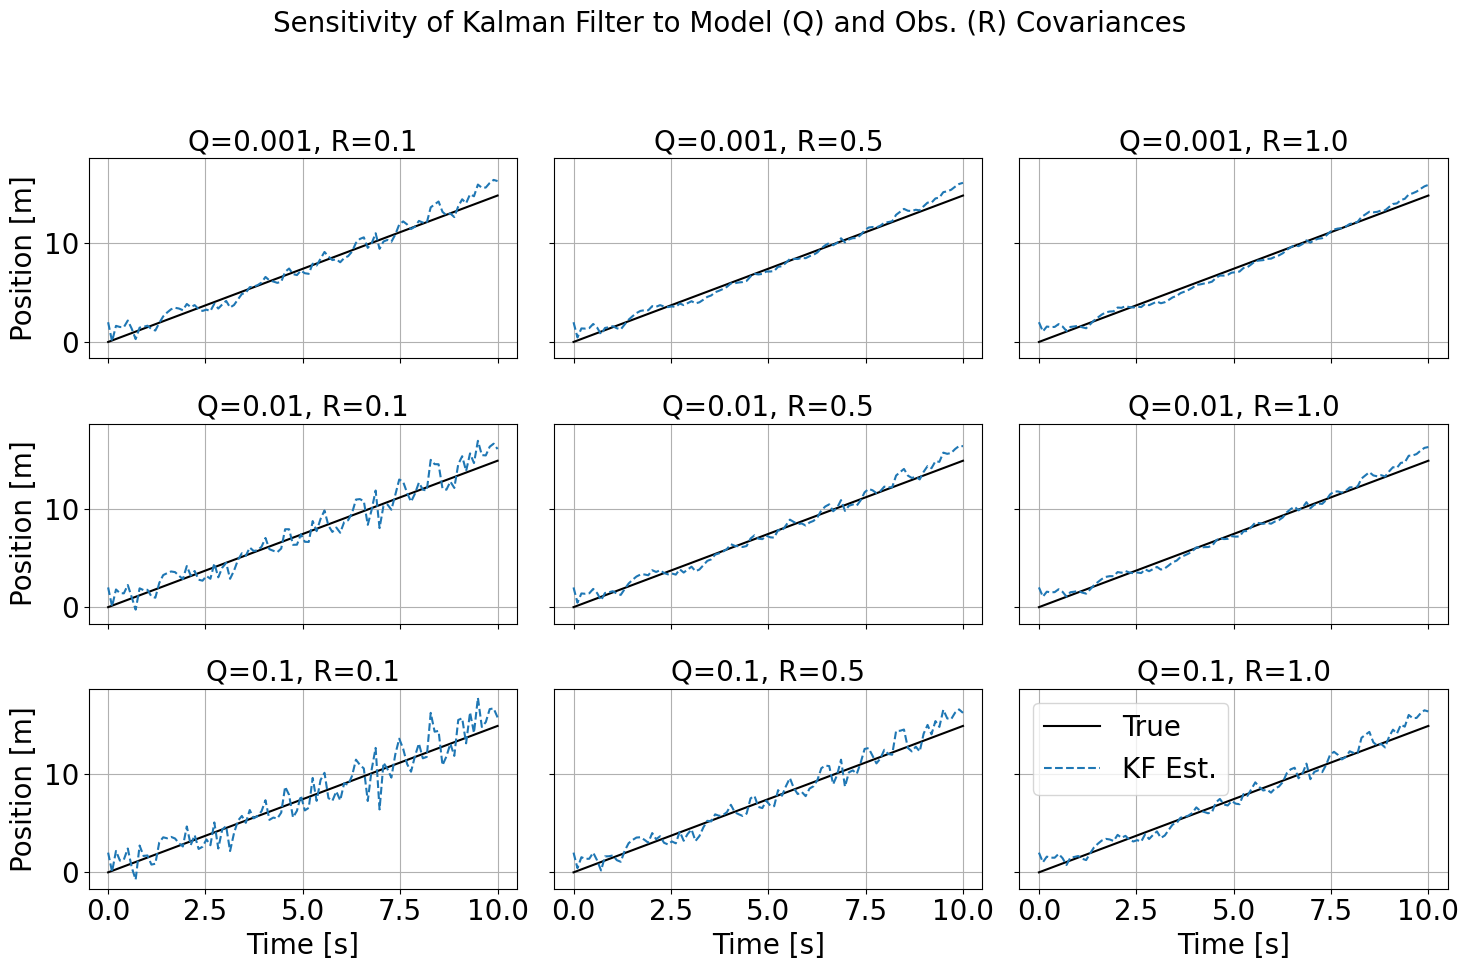

In [39]:
model_noise_levels = [0.001, 0.01, 0.1]
obs_noise_levels = [0.1, 0.5, 1.0]

fig, axs = plt.subplots(len(model_noise_levels), len(obs_noise_levels), figsize=(15, 10), sharex=True, sharey=True)

for i, q in enumerate(model_noise_levels):
    for j, r in enumerate(obs_noise_levels):
        Q = np.array([[q, 0], [0, q]])
        R = np.array([[r**2]])
        x_kf = np.zeros((steps, 2))
        x_kf[0] = [2.0, 1.0]
        P = np.eye(2)

        for k in range(1, steps):
            x_pred = F @ x_kf[k-1]
            P_pred = F @ P @ F.T + Q
            y = y_obs[k] - H @ x_pred
            S = H @ P_pred @ H.T + R
            K = P_pred @ H.T @ np.linalg.inv(S)
            x_kf[k] = x_pred + K @ y
            P = (I - K @ H) @ P_pred

        ax = axs[i, j]
        ax.plot(time, x_true[:, 0], label='True', color='black')
        ax.plot(time, x_kf[:, 0], label='KF Est.', linestyle='--')
        ax.set_title(f'Q={q}, R={r}')
        if i == len(model_noise_levels)-1: ax.set_xlabel('Time [s]')
        if j == 0: ax.set_ylabel('Position [m]')
        ax.grid(True)

fig.suptitle('Sensitivity of Kalman Filter to Model (Q) and Obs. (R) Covariances', fontsize=20)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.legend()
plt.show()


## Car Position Estimation with Ensamble Kalman Filter

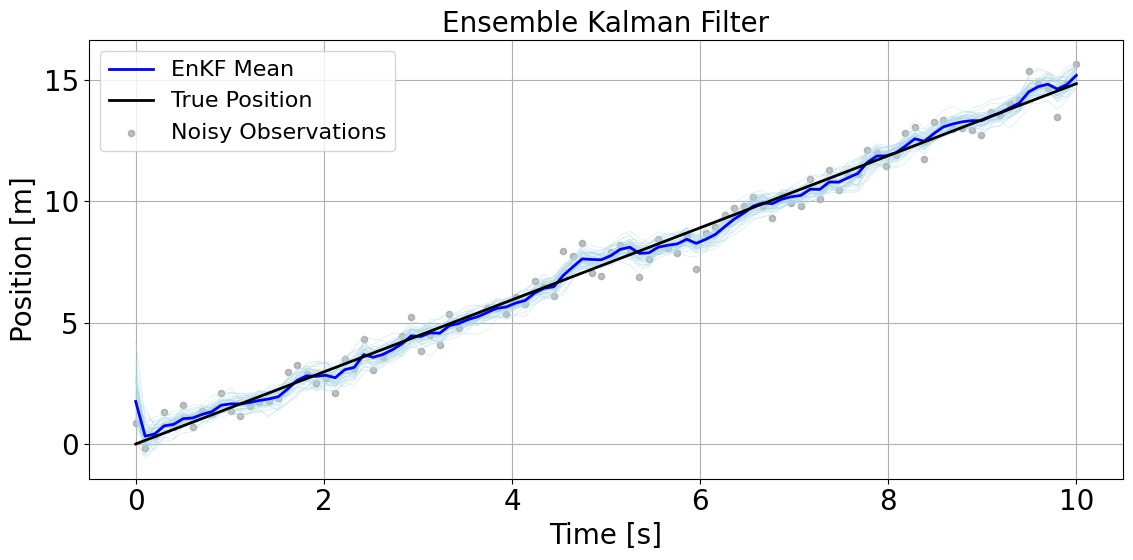

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
dt = 0.1
T = 10
steps = int(T / dt)
time = np.linspace(0, T, steps)
v_true = 1.5
pos_noise_std = 0.5
N = 50  # tamaño del ensemble

# Estado verdadero
x_true = np.zeros((steps, 2))
x_true[0] = [0, v_true]
for k in range(1, steps):
    x_true[k, 0] = x_true[k-1, 0] + dt * x_true[k-1, 1]
    x_true[k, 1] = x_true[k-1, 1]

# Observaciones
y_obs = x_true[:, 0] + np.random.normal(0, pos_noise_std, steps)

# Modelo
F = np.array([[1, dt], [0, 1]])
H = np.array([[1, 0]])
Q = np.array([[0.01, 0], [0, 0.01]])
R = np.array([[pos_noise_std**2]])

# Inicializar ensemble
x_ens = np.zeros((steps, N, 2))
x_ens[0, :, 0] = 2.0 + np.random.normal(0, 1.0, N)
x_ens[0, :, 1] = 1.0 + np.random.normal(0, 0.5, N)

x_enkf_mean = np.zeros((steps, 2))
x_enkf_mean[0] = np.mean(x_ens[0], axis=0)

# EnKF loop
for k in range(1, steps):
    # Predicción de cada miembro
    for i in range(N):
        noise = np.random.multivariate_normal([0, 0], Q)
        x_ens[k, i] = F @ x_ens[k-1, i] + noise

    # Estadísticos
    x_mean = np.mean(x_ens[k], axis=0)
    X_prime = x_ens[k] - x_mean
    P_f = (X_prime.T @ X_prime) / (N - 1)

    # Observaciones perturbadas
    y_perturbed = y_obs[k] + np.random.normal(0, pos_noise_std, N)

    # Actualización de cada miembro
    for i in range(N):
        Hx = H @ x_ens[k, i]
        S = H @ P_f @ H.T + R
        K = P_f @ H.T @ np.linalg.inv(S)
        innovation = y_perturbed[i] - Hx
        x_ens[k, i] += (K @ innovation).flatten()

    x_enkf_mean[k] = np.mean(x_ens[k], axis=0)

# Gráfico
plt.figure(figsize=(12, 6))

# Miembros del ensemble
for i in range(N):
    plt.plot(time, x_ens[:, i, 0], color='lightblue', linewidth=0.5, alpha=0.5)

# Media del ensemble y comparaciones
plt.plot(time, x_enkf_mean[:, 0], label='EnKF Mean', color='blue', linewidth=2)
plt.plot(time, x_true[:, 0], label='True Position', color='black', linewidth=2)
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.5)

plt.xlabel('Time [s]', fontsize=20)
plt.ylabel('Position [m]', fontsize=20)
plt.title('Ensemble Kalman Filter', fontsize=20)
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


## 3D-Var

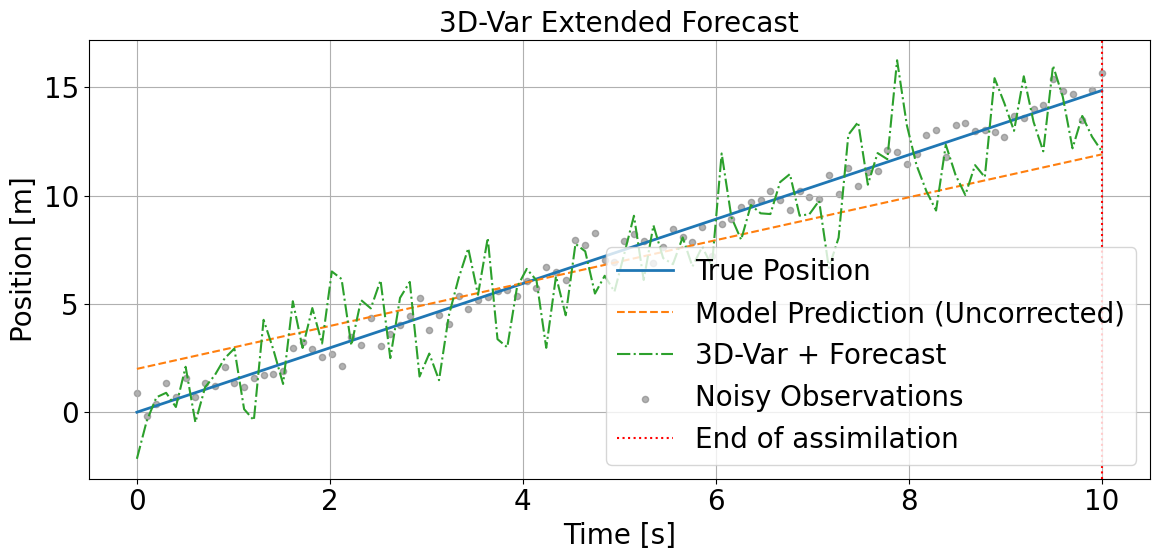

In [ ]:
# Número de pasos adicionales tras la asimilación
extra_steps = 0

# Nueva dimensión de la predicción extendida
x_3dvar_extended = np.zeros((steps + extra_steps, 2))
x_3dvar_extended[:steps] = x_3dvar.copy()

# Extensión de la trayectoria usando el modelo (F)
F = np.array([[1, dt], [0, 1]])  # matriz de transición del modelo

for k in range(steps, steps + extra_steps):
    x_3dvar_extended[k] = F @ x_3dvar_extended[k - 1]

# Extender los vectores tiempo y estado verdadero (para comparación)
time_extended = np.linspace(0, T + extra_steps * dt, steps + extra_steps)
x_true_extended = np.zeros((steps + extra_steps, 2))
x_true_extended[:steps] = x_true.copy()
for k in range(steps, steps + extra_steps):
    x_true_extended[k, 0] = x_true_extended[k-1, 0] + dt * x_true_extended[k-1, 1]
    x_true_extended[k, 1] = x_true_extended[k-1, 1]

# Plot extendido
plt.figure(figsize=(12, 6))
plt.plot(time_extended, x_true_extended[:, 0], label='True Position', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--')
plt.plot(time_extended, x_3dvar_extended[:, 0], label='3D-Var + Forecast', linestyle='-.')
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.6)
#plt.axvline(x=time[-1], color='red', linestyle=':', label='End of assimilation')
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.title('3D-Var Extended Forecast')
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


## 4D-Var

In [19]:
from scipy.optimize import minimize

# Parámetros
B = np.diag([1.0, 1.0])   # Background covariance
R = np.array([[pos_noise_std**2]])
H = np.array([[1, 0]])

# Modelo lineal
def model_propagate(x0, steps, F):
    traj = np.zeros((steps, 2))
    traj[0] = x0
    for k in range(1, steps):
        traj[k] = F @ traj[k-1]
    return traj

# Cost function parametrizada por la ventana
def J(x0, window):
    x0 = np.array(x0)
    traj = model_propagate(x0, window, F)
    innov = y_obs[:window] - traj[:, 0]
    obs_term = np.sum((innov**2) / R[0, 0])
    back_term = (x0 - x_model[0]).T @ np.linalg.inv(B) @ (x0 - x_model[0])
    return 0.5 * (obs_term + back_term)

# Longitud de la ventana deseada
window = 50  # por ejemplo, 3 segundos si dt = 0.1

# Minimización con la ventana seleccionada
res = minimize(J, x0=np.array([2.0, 1.0]), args=(window,), method='L-BFGS-B')
x0_opt = res.x

# Evolución del estado óptimo hasta el final (o solo la ventana)
x_4dvar = model_propagate(x0_opt, steps, F)


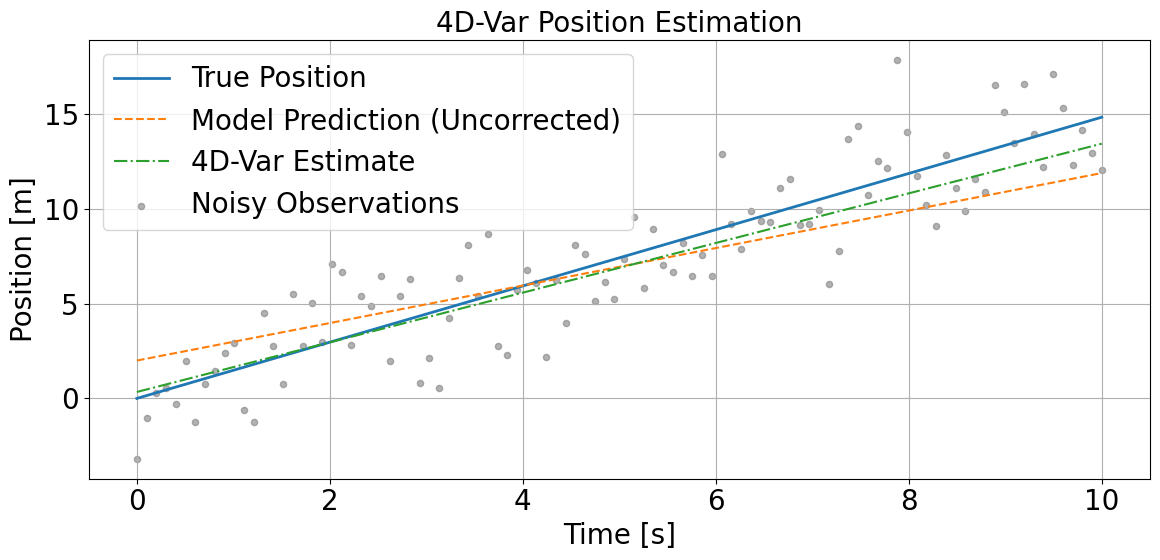

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(time, x_true[:, 0], label='True Position', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--')
plt.plot(time, x_4dvar[:, 0], label='4D-Var Estimate', linestyle='-.')
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.6)
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.title('4D-Var Position Estimation')
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()
